# GWTC-4 primary mass-mass ratio-spin inference
#### Code: [gppop/spin-q-dev](https://github.com/AnaryaRay1/gppop/tree/spin-dev)

#### Contents 

- [Preamble](#Preamble), need to run.
- [Prepare Input for GWTC-4](#Prepare-input-for-GWTC-3)
- [Run Inference](#Run-inference)
- [GP sanity checks](#GP-sanity-checks)



## Preamble

In [1]:
import numpy as np
import pandas as pd
import h5py
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator,LogLocator,NullFormatter)
from matplotlib.colors import LogNorm
from matplotlib.colors import Normalize
import glob
import yaml
from astropy.cosmology import Planck15,z_at_value
from astropy import units as u
from scipy.interpolate import interp1d
import aesara.tensor as tt

In [3]:
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['font.family'] = 'Times New Roman'
matplotlib.rcParams['font.sans-serif'] = ['Bitstream Vera Sans']
matplotlib.rcParams['text.usetex'] = True
matplotlib.rcParams['mathtext.fontset'] = 'cm'
matplotlib.rcParams['axes.unicode_minus'] = False
matplotlib.rcParams.update(matplotlib.rcParamsDefault)

import seaborn as sns
sns.set_context('talk')
sns.set_style('ticks')
sns.set_palette('colorblind')
colors=sns.color_palette('colorblind')
fs=80

In [4]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF

In [5]:
import pymc as pm

In [6]:
import arviz as az

In [7]:
from gwdistributions.distributions.spin.effective import IsotropicUniformMagnitudeChiEffGivenComponentMass

/home/omkar.sridhar/.conda/envs/gppop-dev-spin2/lib/python3.9/site-packages/gwdistributions/transforms/location.py:10: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  from lal.lal import GreenwichMeanSiderealTime as GMST


The pyseobnr package has failed to load, you will not be able to employ SEOBNRv5 approximants.


In [8]:
from gppop.core_m1qchi import Utils_spins_with_q,Vt_Utils_spins_with_q, Rates_spins_with_q

In [9]:
from gppop.core_m1qchi import log_prob_spin, reweight_pinjection

In [10]:
mbins = np.logspace(np.log10(5), np.log10(200), 23)
chi_bins = np.array([-0.7,-0.6,-0.4,-0.3,-0.2,-0.1,-0.05, 0.0, 0.05, 0.1, 0.15,0.2,0.3,0.4,0.6,0.7])
qbins = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])

In [11]:
utils = Utils_spins_with_q(mbins,qbins,chi_bins,kappa=2.7)

## Prepare input for GWTC-4
Needs data on CIT to run, can skip directly to [this cell](#Plot-results)

In [12]:
Zs = np.linspace(0.,10,1000)
DLs = Planck15.luminosity_distance(Zs).value
z_interp = interp1d(DLs,Zs)

In [13]:
import os

In [14]:
with open('../gwtc-4.yaml', "r") as stream:
    config = yaml.full_load(stream)

In [15]:
spin_prior = IsotropicUniformMagnitudeChiEffGivenComponentMass()
spin_prior._init_values(max_spin_magnitude=0.99)

In [16]:
N=1e6
import tqdm
for filename in tqdm.tqdm(config['pe_summary_event_dict'].values()):
    
    with h5py.File(filename[1],'r') as hf:
        try:
            if len(filename[0])>0:
                posterior = hf[filename[0]]['posterior_samples'][()]
            else:
                posterior = hf['posterior_samples'][()]
        except KeyError:
            
            posterior = hf['posterior']
            
        m1 = posterior['mass_1_source']
        if N>len(m1):
            N=len(m1)
        
print(N)

N_samples = N
np.random.seed(2**31-78)

spin_priors = [ ]


posterior_samples_o4 = np.zeros((len(config['pe_summary_event_dict'].keys()),N_samples,4))
for i,filename in enumerate(tqdm.tqdm(config['pe_summary_event_dict'].values())):
    
    testkey=False
    
    with h5py.File(filename[1],'r') as hf:
        try:
            if len(filename[0])>0:
                posterior = hf[filename[0]]['posterior_samples'][()]
            else:
                posterior = hf['posterior_samples'][()]
            this_N_samples = len(posterior)
        except KeyError:
            testkey=True
            posterior = hf['posterior']
            this_N_samples = len(posterior['mass_1_source'])
        indices = np.random.choice(this_N_samples,size=N_samples,replace=False)
        
        if not testkey:
            z = posterior['redshift'][indices]
            m1 = posterior['mass_1_source'][indices]
            m2 = posterior['mass_2_source'][indices]
            q = posterior['mass_ratio'][indices]
            chi_eff = posterior['chi_eff'][indices]
        else:
            z = posterior['redshift'][()][indices]
            m1 = posterior['mass_1_source'][()][indices]
            m2 = posterior['mass_2_source'][()][indices]
            q = posterior['mass_ratio'][()][indices]
            chi_eff = posterior['chi_eff'][()][indices]
        posterior_samples_o4[i,:,:] = np.array([m1,q,z,chi_eff]).T
        spin_priors.append(np.exp(spin_prior._logprob(chi_eff,m1,m2,0.99)))
        
posterior_samples_all = posterior_samples_o4.copy()
posterior_samples_o4 = [ ]
spin_priors = np.array(spin_priors)

100%|██████████| 153/153 [01:51<00:00,  1.37it/s]


1993


  0%|          | 0/153 [00:00<?, ?it/s]/home/omkar.sridhar/.conda/envs/gppop-dev-spin2/lib/python3.9/site-packages/gwdistributions/distributions/spin/effective.py:236: RuntimeWarning: invalid value encountered in log
  ans = q*amax*(4 + 2*be.log(amax) - be.log(q**2*amax**2 - (1+q)**2 * chi**2)) \
/home/omkar.sridhar/.conda/envs/gppop-dev-spin2/lib/python3.9/site-packages/gwdistributions/distributions/spin/effective.py:237: RuntimeWarning: invalid value encountered in arctanh
  - 2*(1+q)*chi * be.arctanh((1+q)*chi/(q*amax)) \
/home/omkar.sridhar/.conda/envs/gppop-dev-spin2/lib/python3.9/site-packages/gwdistributions/distributions/spin/effective.py:253: RuntimeWarning: invalid value encountered in arctanh
  - 2*(1+q)*chi*be.arctanh(q*amax/((1+q)*chi)) \
/home/omkar.sridhar/.conda/envs/gppop-dev-spin2/lib/python3.9/site-packages/gwdistributions/distributions/spin/effective.py:254: RuntimeWarning: invalid value encountered in log
  - q*amax*be.log((1+q)**2*chi**2 - q**2*amax**2) \
/home/om

In [17]:
posterior_samples_all.shape


(153, 1993, 4)

In [18]:
spin_priors = np.array(spin_priors)
spin_priors[np.where(np.isnan(spin_priors))]=np.nanmin(spin_priors)

In [19]:
log_bin_centers=utils.generate_log_bin_centers()
tril_deltaLogbin = utils.arraynd_to_tril(utils.deltaLogbin(), utils.construct_arg_mat())

In [20]:
arg_mat_spin = utils.construct_arg_mat()

In [21]:
weights = [ ]
wt_means = [ ]
wt_sigmas = [ ]
for i,posterior_samples_this_event in enumerate(posterior_samples_all):
    weight_set = utils.compute_weights(posterior_samples_this_event,chi_prior=spin_priors[i], O4_prior = True)
    weights.append(utils.arraynd_to_tril(weight_set[0], arg_mat_spin))
    wt_means.append(utils.arraynd_to_tril(weight_set[1], arg_mat_spin))
    wt_sigmas.append(utils.arraynd_to_tril(weight_set[2], arg_mat_spin))
    #weights.append(compute_weights_with_q(utils, posterior_samples_this_event,chi_prior=spin_priors[i]))
    if i%10==0:
        print(i)

0
10
20
30
40
50
60
70
80
90
100
110
120
130
140
150


In [22]:
weights = np.array(weights)
wt_means = np.array(wt_means)
wt_sigmas = np.array(wt_sigmas)

In [23]:
weights_norm = np.sum(weights, axis = 1)
weights_cut = (weights.T / weights_norm).T
weights_cut.shape

(153, 2445)

In [24]:
data_dir = 'data/'
if not(os.path.exists(data_dir)):
    os.makedirs(data_dir)
os.chdir('data/')

In [25]:
wts_sum = np.sum(weights_cut,axis=0)

In [26]:
w= utils.construct_1dtond_matrix(len(mbins)-1,wts_sum,nbins_chi=len(chi_bins)-1, nbins_q = len(qbins) - 1)

(22, 9, 15)


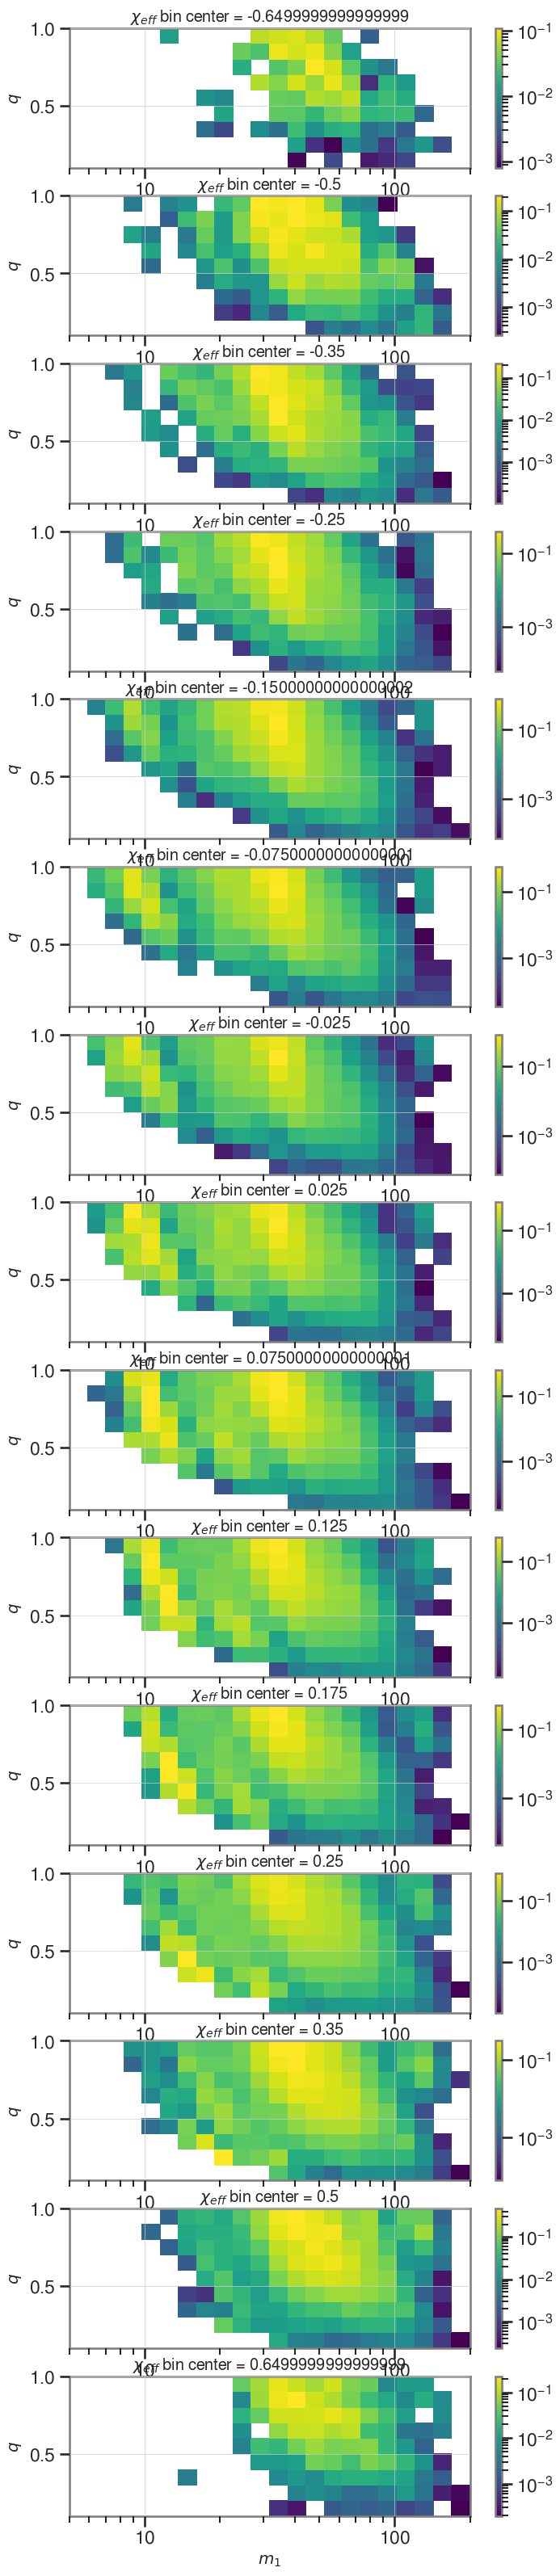

In [27]:
fig,axes = plt.subplots(len(chi_bins)-1,figsize=(8,40))
wts_sum = np.sum(weights,axis=0)
w= utils.construct_1dtond_matrix(len(mbins)-1,wts_sum,nbins_chi=len(chi_bins)-1, nbins_q = len(qbins) - 1)
#w = wts_sum
print(w.shape)
for i in range(len(chi_bins)-1):
        ax = axes[i]
        ax.set_title(r'$\chi_{eff}$ bin center = '+str(0.5*(chi_bins[i+1]+chi_bins[i])))
        matrix1 = w[:,:,i]
        if(matrix1.min()==matrix1.max()):
            continue

        pc = ax.pcolor(mbins,qbins,matrix1.T,norm=LogNorm(vmin=matrix1[matrix1!=0].min(),vmax=matrix1.max()),cmap='viridis')
        ax.set_xscale('log')
        #ax.set_yscale('log')
        ax.set_xlabel(r'$m_1$')
        ax.set_ylabel(r'$q$')
        plt.colorbar(pc, ax = ax)
    #fig.colorbar()
plt.show()
#plt.savefig('weights_chi_bin_center_plots_case_9mdo.pdf')

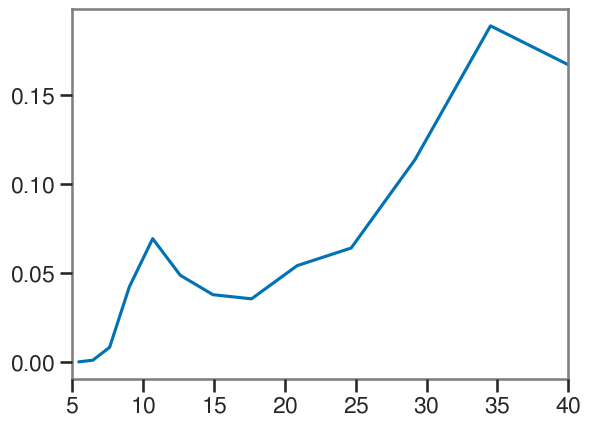

In [28]:
w_marg = np.mean(w,axis = (1,2))
plt.plot(0.5 * (mbins[:-1]+mbins[1:]), w_marg)
plt.xlim(5, 40)
plt.grid()
plt.show()

In [29]:
vt_utils = Vt_Utils_spins_with_q(mbins,qbins,chi_bins,kappa=2.7)

In [30]:
inj_dataset = {}
with h5py.File(config['injection_file'],'r') as hf:
    #print(hf['events'][()].dtype)
    
    m2 = hf["events"][()]["mass2_source"]
    inj_dataset['analysis_time_s'] = hf.attrs['total_analysis_time'] # years
    inj_dataset['total_generated'] = hf.attrs['total_generated']
    mix_weights = hf['events'][()]['weights']
    for param,key in config['injection_keys'].items():
            inj_dataset[param] = hf['events'][()][key]

chi_eff = (inj_dataset['mass1_source']*inj_dataset['spin1z']+
           inj_dataset['mass2_source']*inj_dataset['spin2z'])/(inj_dataset['mass1_source']+
                                                                        inj_dataset['mass2_source'])
inj_dataset['p_draw_chi_given_m1m2'] = np.exp(spin_prior._logprob(chi_eff,inj_dataset['mass1_source'],inj_dataset['mass2_source'],0.99))
thresh = config['threshold']
thresh_keys = config['threshold_keys']
for key in thresh_keys:
    if 'o1o2' in key:
        continue
    inj_dataset[key] = 1./inj_dataset[key] 
inj_dataset["mixture_weight"] = mix_weights
inj_dataset["sampling_pdf"] = np.exp(inj_dataset["sampling_pdf"])

In [31]:
vt_means,vt_sigmas = vt_utils.compute_VTs(inj_dataset,thresh,key = thresh_keys )

In [32]:
vts_nd = utils.construct_1dtond_matrix(len(mbins)-1,vt_means,nbins_chi=len(chi_bins)-1, nbins_q = len(qbins) - 1)

In [33]:
wbyv = wts_sum/(vt_means + 1e-30)

In [34]:
nbins_m = len(mbins)-1
#nbins_m = int(nbins_m*(nbins_m+1))
nbins_q = len(qbins) - 1 
nbins_chi = len(chi_bins)-1

In [35]:
args = np.where(wbyv > 1e20)[0]
args

array([ 495,  645, 1095, 1365, 1920, 2190])

In [36]:
def interpolate_vts(log_bin_centers,tril_deltaLogbin,tril_vts,arg=None):
        '''
        Function for interpolating VTs over bins that have no injections
        using a GP regressor.
        
        Parameters
        ----------
        
        tril_vts  :: numpy.ndarray
                     1d array containing VT meands or stds to be interpolated.
        
        arg       :: numpy.ndarray
                     1d array containing bin indices at which interpolated
                     VTs need to be calculated.
                     
        Returns
        -------
        
        new_vts  : numpy.ndarray
                   interpolated VTs.
        '''
        if(all(tril_vts>0) or arg is None):
            return tril_vts
        
        vts = tril_vts/tril_deltaLogbin
        X =log_bin_centers[vts!=0]
        y = np.log((vts)[vts!=0])
        kernel = RBF(length_scale=0.3,length_scale_bounds=[0.08,2])
        gp = GaussianProcessRegressor(kernel=kernel,n_restarts_optimizer=5).fit(X,y)
        y_pred = gp.predict(log_bin_centers[arg.astype(int)])
        vt_pred = np.exp(y_pred)
        new_vts = vts.copy()
        new_vts[arg.astype(int)] = vt_pred
        print(vt_pred)
        return new_vts*tril_deltaLogbin

In [37]:
interp_vts = interpolate_vts(log_bin_centers,tril_deltaLogbin,vt_means,arg=args)

/home/omkar.sridhar/.conda/envs/gppop-dev-spin2/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:420: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 0.08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


[0.73116724 3.56605937 1.19798031 0.4186365  6.60298095
 5.58286723]


In [38]:
vt_means[args], interp_vts[args], wbyv[args]

(array([0., 0., 0., 0., 0., 0.]),
 array([0.00122599, 0.00597944, 0.00200873, 0.00070195,
        0.01107164, 0.00936115]),
 array([5.02884539e+27, 7.91288802e+27, 8.69719745e+26,
        2.52451242e+27, 5.70519788e+27, 2.68814997e+27]))

In [39]:
ivts_nd = utils.construct_1dtond_matrix(len(mbins)-1,interp_vts,nbins_chi=len(chi_bins)-1, nbins_q = len(qbins) - 1)
wbyvfinal = w/(ivts_nd + 1e-30)
np.where(wbyvfinal > 1e10)

(array([], dtype=int64), array([], dtype=int64), array([], dtype=int64))

In [40]:
dist_array = np.zeros(int(nbins_m*(nbins_m+1)))

chi_bin_centers = 0.5 * (chi_bins[1:] + chi_bins[:-1])
q_bin_centers = 0.5 * (qbins[1:] + qbins[:-1])
logm_bin_centers = 0.5 * (np.log(mbins[1:]) + np.log(mbins[:-1]))
k=0
for i in range(len(logm_bin_centers)):
    for j in range(i+1):
        dist_array[k] = np.linalg.norm(logm_bin_centers[i]-logm_bin_centers[j])
        k+=1

scale_min = np.log(np.min(dist_array[dist_array!=0.]))
scale_max = np.log(np.max(dist_array))
scale_mean_m = 0.5*(scale_min + scale_max) # chosen to give coverage over the bin-grid
scale_sd_m = (scale_max - scale_min)/4 # fix 3-sigma difference to the sd of the length scale dist

dist_array = np.zeros(int(nbins_q*(nbins_q+1)))
k=0
for i in range(len(q_bin_centers)):
    for j in range(i+1):
        dist_array[k] = np.linalg.norm(q_bin_centers[i]-q_bin_centers[j])
        k+=1

scale_min = np.log(np.min(dist_array[dist_array!=0.]))
scale_max = np.log(np.max(dist_array))
scale_mean_q = 0.5*(scale_min + scale_max) # chosen to give coverage over the bin-grid
scale_sd_q = (scale_max - scale_min)/4 # fix 3-sigma difference to the sd of the length scale dist
print(scale_mean_m,scale_sd_m,scale_mean_q,scale_sd_q)

dist_array = np.zeros(int(nbins_chi*(nbins_chi+1)))
k=0
for i in range(len(chi_bin_centers)):
    for j in range(i+1):
        dist_array[k] = np.linalg.norm(chi_bin_centers[i]-chi_bin_centers[j])
        k+=1

scale_min = np.log(np.min(dist_array[dist_array!=0.]))
scale_max = np.log(np.max(dist_array))
scale_mean_chi = 0.5*(scale_min + scale_max) # chosen to give coverage over the bin-grid
scale_sd_chi = (scale_max - scale_min)/4 # fix 3-sigma difference to the sd of the length scale dist
print(scale_mean_chi,scale_sd_chi)

-0.26345849353336925 0.7611306094308565 -1.2628643221541282 0.5198603854199593
-1.3666840045432502 0.8145241345053705


In [41]:
scales_m = np.array([scale_mean_m,scale_sd_m])
scales_q = np.array([scale_mean_q,scale_sd_q])
scales_chi = np.array([scale_mean_chi,scale_sd_chi])

In [42]:
with h5py.File("GWTC-4-m1qchi.h5", "w") as f:  
    # Add variables
    gppop_data = f.create_group('gppop_metadata')
    gppop_data.create_dataset("mbins", data=mbins)
    gppop_data.create_dataset("qbins", data=qbins)
    gppop_data.create_dataset("chi_bins", data=chi_bins)
    gppop_data.create_dataset("scales_m", data=scales_m)
    gppop_data.create_dataset("scales_q", data=scales_q)
    gppop_data.create_dataset("scales_chi", data=scales_chi)    
    gppop_data.create_dataset("posterior_weights", data=weights_cut)
    gppop_data.create_dataset("vts", data=interp_vts/tril_deltaLogbin)
    gppop_data.create_dataset("vt_means", data=vt_means)
    gppop_data.create_dataset("vt_sigmas", data=vt_sigmas)
    gppop_data.create_dataset("wt_means", data=wt_means)
    gppop_data.create_dataset("wt_sigmas", data=wt_sigmas)